# Time Series

In [2]:
import pandas as pd

ModuleNotFoundError: No module named 'pandas'

## 2.1.  Converting to timestamps 

In [ ]:
pd.to_datetime(pd.Series(["Jul 31, 2009", "2010-01-10", None]))

ValueError: time data "2010-01-10" doesn't match format "%b %d, %Y", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
 pd.to_datetime(["2005/11/23", "2010.12.31"])

DatetimeIndex(['2005-11-23', '2010-12-31'], dtype='datetime64[ns]', freq=None)

dayfirst flag 

In [ ]:
pd.to_datetime(["04-01-2012 10:00"], dayfirst=True)

DatetimeIndex(['2012-01-04 10:00:00'], dtype='datetime64[ns]', freq=None)

In [ ]:
pd.to_datetime(["14-01-2012", "01-14-2012"], dayfirst=True, infer_datetime_format=True)

/var/folders/k3/93bf5ryn5057n3c5qrfhj_540000gn/T/ipykernel_71237/1095608395.py:1: UserWarning: Parsing '01-14-2012' in MM/DD/YYYY format. Provide format or specify infer_datetime_format=True for consistent parsing.
  pd.to_datetime(["14-01-2012", "01-14-2012"], dayfirst=True, infer_datetime_format=True)


DatetimeIndex(['2012-01-14', '2012-01-14'], dtype='datetime64[ns]', freq=None)

In [ ]:
pd.to_datetime("2010/11/12")

Timestamp('2010-11-12 00:00:00')

In [ ]:
pd.Timestamp("2010/11/12")

Timestamp('2010-11-12 00:00:00')

In [ ]:
pd.DatetimeIndex(["2018-01-01", "2018-01-03", "2018-01-05"])

DatetimeIndex(['2018-01-01', '2018-01-03', '2018-01-05'], dtype='datetime64[ns]', freq=None)

In [ ]:
#‘infer’ can be passed in order to set the frequency of the index as the inferred frequency upon creation
pd.DatetimeIndex(["2018-01-01", "2018-01-03", "2018-01-02"], freq="infer")

DatetimeIndex(['2018-01-01', '2018-01-03', '2018-01-02'], dtype='datetime64[ns]', freq=None)

### 2.1.1. Providing a format argument 

In [ ]:
pd.to_datetime("2010/11/12", format="%Y/%m/%d")

Timestamp('2010-11-12 00:00:00')

In [ ]:
pd.to_datetime("12-11-2010 00:00", format="%d-%m-%Y %H:%M")

Timestamp('2010-11-12 00:00:00')

### 2.1.2. Assembling datetime from multiple DataFrame columns 

In [ ]:
df = pd.DataFrame(
     {"year": [2015, 2016], "month": [2, 3], "day": [4, 5], "hour": [2, 3]}
     )
pd.to_datetime(df)

0   2015-02-04 02:00:00
1   2016-03-05 03:00:00
dtype: datetime64[ns]

In [ ]:
 pd.to_datetime(df[["year", "month", "day"]])

0   2015-02-04
1   2016-03-05
dtype: datetime64[ns]

<b>pd.to_datetime</b> looks for standard designations of the datetime component in the column names, including:
 
     • required: year, month, day
     • optional: hour, minute, second, millisecond, microsecond, nanosecond

### 2.1.3. Invalid data 

In [ ]:
pd.to_datetime(['2009/07/31', 'asd'], errors='raise')

ParserError: Unknown string format: asd

In [ ]:
pd.to_datetime(["2009/07/31", "asd"], errors="ignore")

Index(['2009/07/31', 'asd'], dtype='object')

In [ ]:
 pd.to_datetime(["2009/07/31", "asd"], errors="coerce")

DatetimeIndex(['2009-07-31', 'NaT'], dtype='datetime64[ns]', freq=None)

### 2.1.4. Epoch timestamps 

In [ ]:
pd.to_datetime(
     [1349720105, 1349806505, 1349892905, 1349979305, 1350065705], unit="s"
     )

DatetimeIndex(['2012-10-08 18:15:05', '2012-10-09 18:15:05',
               '2012-10-10 18:15:05', '2012-10-11 18:15:05',
               '2012-10-12 18:15:05'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
 pd.to_datetime(
     [1349720105100, 1349720105200, 1349720105300, 1349720105400,1349720105500],
     unit="ms",
     )

DatetimeIndex(['2012-10-08 18:15:05.100000', '2012-10-08 18:15:05.200000',
               '2012-10-08 18:15:05.300000', '2012-10-08 18:15:05.400000',
               '2012-10-08 18:15:05.500000'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
 pd.Timestamp(1262347200000000000).tz_localize("Asia/Atyrau")

Timestamp('2010-01-01 12:00:00+0500', tz='Asia/Atyrau')

In [ ]:
pd.DatetimeIndex([1262347200000000000]).tz_localize("Asia/Atyrau")

DatetimeIndex(['2010-01-01 12:00:00+05:00'], dtype='datetime64[ns, Asia/Atyrau]', freq=None)

<b>!</b> Epoch times will be rounded to the nearest nanosecond

In [ ]:
#Warning!#

pd.to_datetime([1490195805.433, 1490195805.433502912], unit="s")

DatetimeIndex(['2017-03-22 15:16:45.433000088', '2017-03-22 15:16:45.433502913'], dtype='datetime64[ns]', freq=None)

In [ ]:
pd.to_datetime(1490195805433502912, unit="ns")

Timestamp('2017-03-22 15:16:45.433502912')

### 2.1.5. From timestamps to epoch 

In [ ]:
stamps = pd.date_range("2012-10-08 18:15:05", periods=4, freq="D")
stamps

DatetimeIndex(['2012-10-08 18:15:05', '2012-10-09 18:15:05',
               '2012-10-10 18:15:05', '2012-10-11 18:15:05'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
(stamps - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")

Int64Index([1349720105, 1349806505, 1349892905, 1349979305], dtype='int64')

In [ ]:
pd.to_datetime(1349720105, unit = 's')

Timestamp('2012-10-08 18:15:05')

In [ ]:
# 1970-01-01 UNIX TIME

### 2.1.6. Using the origin Parameter

In [ ]:
pd.to_datetime([1, 2, 3], unit="D", origin=pd.Timestamp("1960-01-01"))

DatetimeIndex(['1960-01-02', '1960-01-03', '1960-01-04'], dtype='datetime64[ns]', freq=None)

In [ ]:
pd.to_datetime([1, 2, 3], unit="D")

DatetimeIndex(['1970-01-02', '1970-01-03', '1970-01-04'], dtype='datetime64[ns]', freq=None)

## 2.2. Generating ranges of timestamps 

In [ ]:
import datetime

In [ ]:
dates = [
     datetime.datetime(2012, 5, 1),
     datetime.datetime(2012, 5, 2),
     datetime.datetime(2012, 5, 3),
     ]

In [ ]:
print(dates)

[datetime.datetime(2012, 5, 1, 0, 0), datetime.datetime(2012, 5, 2, 0, 0), datetime.datetime(2012, 5, 3, 0, 0)]


In [ ]:
# Note the frequency information
index = pd.DatetimeIndex(dates)

In [ ]:
index

DatetimeIndex(['2012-05-01', '2012-05-02', '2012-05-03'], dtype='datetime64[ns]', freq=None)

In [ ]:
# Automatically converted to DatetimeIndex
index = pd.Index(dates)
index

DatetimeIndex(['2012-05-01', '2012-05-02', '2012-05-03'], dtype='datetime64[ns]', freq=None)

In [ ]:
start = datetime.datetime(2011, 1, 1)
end = datetime.datetime(2012, 1, 1)
index = pd.date_range(start, end)
index

DatetimeIndex(['2011-01-01', '2011-01-02', '2011-01-03', '2011-01-04',
               '2011-01-05', '2011-01-06', '2011-01-07', '2011-01-08',
               '2011-01-09', '2011-01-10',
               ...
               '2011-12-23', '2011-12-24', '2011-12-25', '2011-12-26',
               '2011-12-27', '2011-12-28', '2011-12-29', '2011-12-30',
               '2011-12-31', '2012-01-01'],
              dtype='datetime64[ns]', length=366, freq='D')

In [ ]:
index = pd.bdate_range(start, end)
index   

DatetimeIndex(['2011-01-03', '2011-01-04', '2011-01-05', '2011-01-06',
               '2011-01-07', '2011-01-10', '2011-01-11', '2011-01-12',
               '2011-01-13', '2011-01-14',
               ...
               '2011-12-19', '2011-12-20', '2011-12-21', '2011-12-22',
               '2011-12-23', '2011-12-26', '2011-12-27', '2011-12-28',
               '2011-12-29', '2011-12-30'],
              dtype='datetime64[ns]', length=260, freq='B')

                                       business daily ---^

In [ ]:
 pd.date_range(start, periods=1000, freq="M")

DatetimeIndex(['2011-01-31', '2011-02-28', '2011-03-31', '2011-04-30',
               '2011-05-31', '2011-06-30', '2011-07-31', '2011-08-31',
               '2011-09-30', '2011-10-31',
               ...
               '2093-07-31', '2093-08-31', '2093-09-30', '2093-10-31',
               '2093-11-30', '2093-12-31', '2094-01-31', '2094-02-28',
               '2094-03-31', '2094-04-30'],
              dtype='datetime64[ns]', length=1000, freq='M')

In [ ]:
pd.bdate_range(start, periods=250, freq="BQS") #business quarter start frequency

DatetimeIndex(['2011-01-03', '2011-04-01', '2011-07-01', '2011-10-03',
               '2012-01-02', '2012-04-02', '2012-07-02', '2012-10-01',
               '2013-01-01', '2013-04-01',
               ...
               '2071-01-01', '2071-04-01', '2071-07-01', '2071-10-01',
               '2072-01-01', '2072-04-01', '2072-07-01', '2072-10-03',
               '2073-01-02', '2073-04-03'],
              dtype='datetime64[ns]', length=250, freq='BQS-JAN')

In [ ]:
pd.date_range(start, end, freq="BM")

DatetimeIndex(['2011-01-31', '2011-02-28', '2011-03-31', '2011-04-29',
               '2011-05-31', '2011-06-30', '2011-07-29', '2011-08-31',
               '2011-09-30', '2011-10-31', '2011-11-30', '2011-12-30'],
              dtype='datetime64[ns]', freq='BM')

In [ ]:
 pd.date_range(start, end, freq="W")

DatetimeIndex(['2011-01-02', '2011-01-09', '2011-01-16', '2011-01-23',
               '2011-01-30', '2011-02-06', '2011-02-13', '2011-02-20',
               '2011-02-27', '2011-03-06', '2011-03-13', '2011-03-20',
               '2011-03-27', '2011-04-03', '2011-04-10', '2011-04-17',
               '2011-04-24', '2011-05-01', '2011-05-08', '2011-05-15',
               '2011-05-22', '2011-05-29', '2011-06-05', '2011-06-12',
               '2011-06-19', '2011-06-26', '2011-07-03', '2011-07-10',
               '2011-07-17', '2011-07-24', '2011-07-31', '2011-08-07',
               '2011-08-14', '2011-08-21', '2011-08-28', '2011-09-04',
               '2011-09-11', '2011-09-18', '2011-09-25', '2011-10-02',
               '2011-10-09', '2011-10-16', '2011-10-23', '2011-10-30',
               '2011-11-06', '2011-11-13', '2011-11-20', '2011-11-27',
               '2011-12-04', '2011-12-11', '2011-12-18', '2011-12-25',
               '2012-01-01'],
              dtype='datetime64[ns]', freq='W-S

In [ ]:
 pd.bdate_range(end=end, periods=20)

DatetimeIndex(['2011-12-05', '2011-12-06', '2011-12-07', '2011-12-08',
               '2011-12-09', '2011-12-12', '2011-12-13', '2011-12-14',
               '2011-12-15', '2011-12-16', '2011-12-19', '2011-12-20',
               '2011-12-21', '2011-12-22', '2011-12-23', '2011-12-26',
               '2011-12-27', '2011-12-28', '2011-12-29', '2011-12-30'],
              dtype='datetime64[ns]', freq='B')

In [ ]:
 pd.bdate_range(start=start, periods=20)

DatetimeIndex(['2011-01-03', '2011-01-04', '2011-01-05', '2011-01-06',
               '2011-01-07', '2011-01-10', '2011-01-11', '2011-01-12',
               '2011-01-13', '2011-01-14', '2011-01-17', '2011-01-18',
               '2011-01-19', '2011-01-20', '2011-01-21', '2011-01-24',
               '2011-01-25', '2011-01-26', '2011-01-27', '2011-01-28'],
              dtype='datetime64[ns]', freq='B')

In [ ]:
 pd.date_range("2018-01-01", "2018-01-05", periods=5)

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
 pd.date_range("2018-01-01", "2018-01-05", periods=10)

DatetimeIndex(['2018-01-01 00:00:00', '2018-01-01 10:40:00',
               '2018-01-01 21:20:00', '2018-01-02 08:00:00',
               '2018-01-02 18:40:00', '2018-01-03 05:20:00',
               '2018-01-03 16:00:00', '2018-01-04 02:40:00',
               '2018-01-04 13:20:00', '2018-01-05 00:00:00'],
              dtype='datetime64[ns]', freq=None)

### 2.2.1. Custom frequency ranges 

In [ ]:
weekmask = "Mon Wed Fri"
holidays = [datetime.datetime(2011, 1, 5), datetime.datetime(2011, 3, 14)]
pd.bdate_range(start, end, freq="C", weekmask=weekmask, holidays=holidays)

DatetimeIndex(['2011-01-03', '2011-01-07', '2011-01-10', '2011-01-12',
               '2011-01-14', '2011-01-17', '2011-01-19', '2011-01-21',
               '2011-01-24', '2011-01-26',
               ...
               '2011-12-09', '2011-12-12', '2011-12-14', '2011-12-16',
               '2011-12-19', '2011-12-21', '2011-12-23', '2011-12-26',
               '2011-12-28', '2011-12-30'],
              dtype='datetime64[ns]', length=154, freq='C')

In [ ]:
pd.bdate_range(start, end, freq="CBMS", weekmask=weekmask)

DatetimeIndex(['2011-01-03', '2011-02-02', '2011-03-02', '2011-04-01',
               '2011-05-02', '2011-06-01', '2011-07-01', '2011-08-01',
               '2011-09-02', '2011-10-03', '2011-11-02', '2011-12-02'],
              dtype='datetime64[ns]', freq='CBMS')

## 2.3. Timestamp limitations  

In [ ]:
 pd.Timestamp.min

Timestamp('1677-09-21 00:12:43.145224193')

In [ ]:
 pd.Timestamp.max

Timestamp('2262-04-11 23:47:16.854775807')

## 2.4. Indexing 

In [ ]:
import numpy as np

In [ ]:
rng = pd.date_range(start, end, freq="BM")
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts.index

DatetimeIndex(['2011-01-31', '2011-02-28', '2011-03-31', '2011-04-29',
               '2011-05-31', '2011-06-30', '2011-07-29', '2011-08-31',
               '2011-09-30', '2011-10-31', '2011-11-30', '2011-12-30'],
              dtype='datetime64[ns]', freq='BM')

In [ ]:
 ts[:5].index

DatetimeIndex(['2011-01-31', '2011-02-28', '2011-03-31', '2011-04-29',
               '2011-05-31'],
              dtype='datetime64[ns]', freq='BM')

In [ ]:
 ts[::2].index

DatetimeIndex(['2011-01-31', '2011-03-31', '2011-05-31', '2011-07-29',
               '2011-09-30', '2011-11-30'],
              dtype='datetime64[ns]', freq='2BM')

In [ ]:
ts

2011-01-31   -1.340418
2011-02-28    0.928330
2011-03-31   -0.834603
2011-04-29   -0.294304
2011-05-31   -0.470534
2011-06-30    0.671209
2011-07-29    0.587880
2011-08-31   -1.171567
2011-09-30   -0.206852
2011-10-31   -2.372929
2011-11-30   -1.745990
2011-12-30    1.255505
Freq: BM, dtype: float64

### 2.4.1. Partial string indexing 

In [ ]:
ts["1/31/2011"]

-1.340418495837567

In [ ]:
ts[datetime.datetime(2011, 12, 25):]

2011-12-30    1.255505
Freq: BM, dtype: float64

In [ ]:
ts["10/31/2011":"12/31/2011"]

2011-10-31   -2.372929
2011-11-30   -1.745990
2011-12-30    1.255505
Freq: BM, dtype: float64

In [ ]:
ts["2011"]

2011-01-31   -1.340418
2011-02-28    0.928330
2011-03-31   -0.834603
2011-04-29   -0.294304
2011-05-31   -0.470534
2011-06-30    0.671209
2011-07-29    0.587880
2011-08-31   -1.171567
2011-09-30   -0.206852
2011-10-31   -2.372929
2011-11-30   -1.745990
2011-12-30    1.255505
Freq: BM, dtype: float64

In [ ]:
ts["2011-6"]

2011-06-30    0.671209
Freq: BM, dtype: float64

In [ ]:
 dft = pd.DataFrame(
     np.random.randn(100000, 1),
     columns=["A"], 
     index=pd.date_range("20130101", periods=100000, freq="T"),
     )

In [ ]:
dft

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-03-11 10:35:00,0.404095
2013-03-11 10:36:00,1.836255
2013-03-11 10:37:00,-0.017400
2013-03-11 10:38:00,-1.083550


In [ ]:
 dft.loc["2013-1"]

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-01-31 23:55:00,0.768005
2013-01-31 23:56:00,0.547010
2013-01-31 23:57:00,-0.378499
2013-01-31 23:58:00,0.298961


In [ ]:
 dft["2013-1":"2013-2"]

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-02-28 23:55:00,0.299173
2013-02-28 23:56:00,0.850766
2013-02-28 23:57:00,-0.025589
2013-02-28 23:58:00,-0.328096


In [ ]:
 dft["2013-1":"2013-2-28"]

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-02-28 23:55:00,0.299173
2013-02-28 23:56:00,0.850766
2013-02-28 23:57:00,-0.025589
2013-02-28 23:58:00,-0.328096


In [ ]:
dft["2013-1":"2013-2-28 00:00:00"]

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-02-27 23:56:00,-0.683116
2013-02-27 23:57:00,-0.772585
2013-02-27 23:58:00,-0.716002
2013-02-27 23:59:00,-0.791436


In [ ]:
 dft["2013-1-15":"2013-1-15 12:30:00"]

,A
2013-01-15 00:00:00,0.472906
2013-01-15 00:01:00,-1.563027
2013-01-15 00:02:00,1.553794
2013-01-15 00:03:00,-1.132501
2013-01-15 00:04:00,2.211347
...,...
2013-01-15 12:26:00,0.387434
2013-01-15 12:27:00,0.087005
2013-01-15 12:28:00,0.934653
2013-01-15 12:29:00,-0.672134


In [ ]:
dft2 = pd.DataFrame(
     np.random.randn(20, 1),
     columns=["A"],
     index=pd.MultiIndex.from_product(
     [pd.date_range("20130101", periods=10, freq="12H"), ["a", "b"]]
     ),
     )

In [ ]:
dft2

A
2013-01-01 00:00:00 a -0.394665
                    b -2.099401
2013-01-01 12:00:00 a -0.243305
                    b  0.029975
2013-01-02 00:00:00 a  0.354712
                    b -2.155553
2013-01-02 12:00:00 a  0.721920
                    b  1.129629
2013-01-03 00:00:00 a  0.020700
                    b  0.313326
2013-01-03 12:00:00 a -1.770221
                    b  0.552622
2013-01-04 00:00:00 a  0.257397
                    b -1.307903
2013-01-04 12:00:00 a -0.236124
                    b  0.352261
2013-01-05 00:00:00 a  0.406154
                    b -0.100173
2013-01-05 12:00:00 a -0.373550
                    b -0.216529

In [ ]:
 dft2.loc["2013-01-05"]

A
2013-01-05 00:00:00 a  0.406154
                    b -0.100173
2013-01-05 12:00:00 a -0.373550
                    b -0.216529

In [ ]:
idx = pd.IndexSlice
dft2 = dft2.swaplevel(0, 1).sort_index()
dft2.loc[idx[:, "2013-01-05"], :]

A
a 2013-01-05 00:00:00  0.406154
  2013-01-05 12:00:00 -0.373550
b 2013-01-05 00:00:00 -0.100173
  2013-01-05 12:00:00 -0.216529

### 2.4.2. Exact Indexing 

In [ ]:
 dft[datetime.datetime(2013, 1, 1): datetime.datetime(2013, 2, 28)]

,A
2013-01-01 00:00:00,0.320836
2013-01-01 00:01:00,-0.142671
2013-01-01 00:02:00,0.083306
2013-01-01 00:03:00,0.290386
2013-01-01 00:04:00,1.514821
...,...
2013-02-27 23:56:00,-0.683116
2013-02-27 23:57:00,-0.772585
2013-02-27 23:58:00,-0.716002
2013-02-27 23:59:00,-0.791436


In [ ]:
 dft[
     datetime.datetime(2013, 1, 1, 10, 12, 0): datetime.datetime(
     2013, 2, 28, 10, 12, 0
     )
     ]

,A
2013-01-01 10:12:00,-1.712183
2013-01-01 10:13:00,0.685481
2013-01-01 10:14:00,0.189794
2013-01-01 10:15:00,-1.373780
2013-01-01 10:16:00,-2.397625
...,...
2013-02-28 10:08:00,-1.886764
2013-02-28 10:09:00,-0.374624
2013-02-28 10:10:00,-0.716600
2013-02-28 10:11:00,-0.040549


### 2.4.3. Truncating 

In [ ]:
rng2 = pd.date_range("2011-01-01", "2012-01-01", freq="W")
ts2 = pd.Series(np.random.randn(len(rng2)), index=rng2)
ts2.truncate(before="2011-11", after="2011-12")

2011-11-06    1.202591
2011-11-13    0.000824
2011-11-20    1.564600
2011-11-27   -1.297995
Freq: W-SUN, dtype: float64

In [ ]:
ts2["2011-11":"2011-12"]

2011-11-06    1.202591
2011-11-13    0.000824
2011-11-20    1.564600
2011-11-27   -1.297995
2011-12-04   -0.156579
2011-12-11    0.980085
2011-12-18   -0.562198
2011-12-25    0.620179
Freq: W-SUN, dtype: float64

In [ ]:
ts2[[0, 2, 6]].index

DatetimeIndex(['2011-01-02', '2011-01-16', '2011-02-13'], dtype='datetime64[ns]', freq=None)

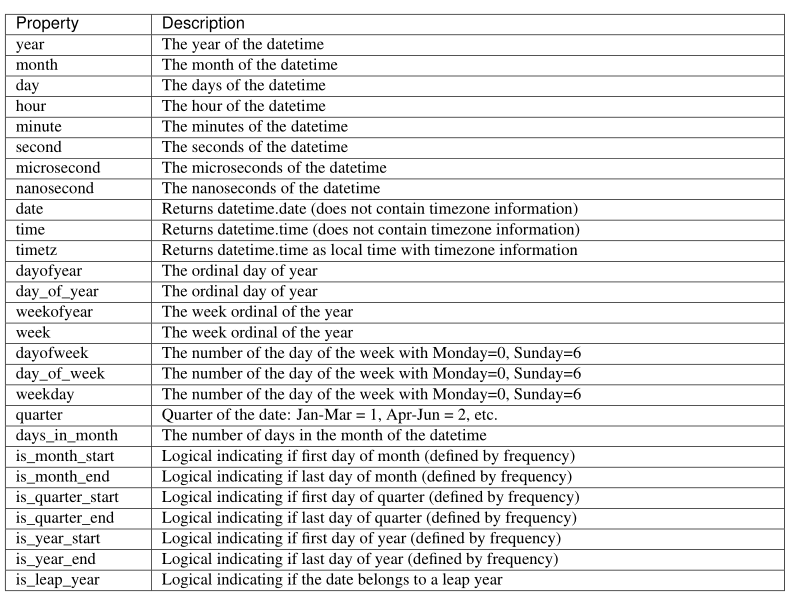

In [ ]:
idx = pd.date_range(start="2019-12-29", freq="D", periods=4)

In [ ]:
idx.isocalendar()

,year,week,day
2019-12-29,2019,52,7
2019-12-30,2020,1,1
2019-12-31,2020,1,2
2020-01-01,2020,1,3


In [ ]:
idx = pd.date_range("2012-01-01", "2015-01-01", freq="Y")
idx

DatetimeIndex(['2012-12-31', '2013-12-31', '2014-12-31'], dtype='datetime64[ns]', freq='A-DEC')

In [ ]:
idx.is_leap_year

array([ True, False, False])

# Exercises: 

1. From the following table of user actions, write a statement to return for each user the time elapsed between the last action and the second-to-last action, in ascending order by user ID.  (Work with first and second user)
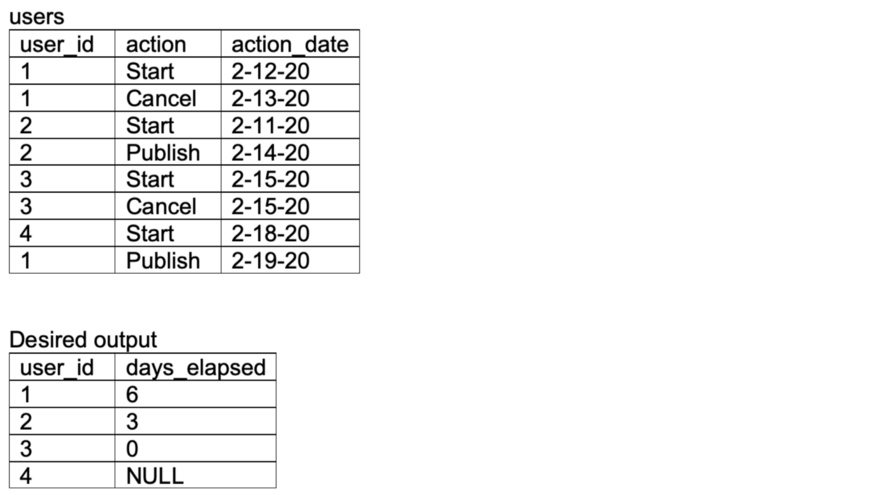

In [ ]:
import pandas as pd

# Создаем DataFrame как в условии
data = {
    'user_id': [1, 1, 2, 2, 3, 3, 4, 1],
    'action':  ['Start','Cancel','Start','Publish','Start','Cancel','Start','Publish'],
    'action_date': ['2-12-20','2-13-20','2-11-20','2-14-20',
                    '2-15-20','2-15-20','2-18-20','2-19-20']
}

df = pd.DataFrame(data)

# Преобразуем даты
df['action_date'] = pd.to_datetime(df['action_date'])

# Сортируем по user и дате
df = df.sort_values(['user_id', 'action_date'])

# Берем последние 2 действия каждого пользователя
df['rn'] = df.groupby('user_id')['action_date'].rank(method='first', ascending=False)

# Last action
last = df[df['rn'] == 1][['user_id', 'action_date']].rename(columns={'action_date': 'last_date'})
# Second-to-last action
second = df[df['rn'] == 2][['user_id', 'action_date']].rename(columns={'action_date': 'second_date'})

# Соединяем
res = last.merge(second, on='user_id', how='left')

# Разница в днях
res['days_elapsed'] = (res['last_date'] - res['second_date']).dt.days

# Выводим только нужные колонки
res[['user_id', 'days_elapsed']].sort_values('user_id')


C:\Users\aslan\AppData\Local\Temp\ipykernel_12424\1728815208.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['action_date'] = pd.to_datetime(df['action_date'])


,user_id,days_elapsed
0,1,6.0
1,2,3.0
2,3,0.0
3,4,NaN


2.  The projects table contains three columns: task_id, start_date, and end_date. The difference between end_date and start_date is 1 day for each row in the table. If task end dates are consecutive they are part of the same project. Projects do not overlap.
    Write a statement to return the start and end dates of each project, and the number of days it took to complete. Order by ascending project duration, and descending start date in the case of a tie.
    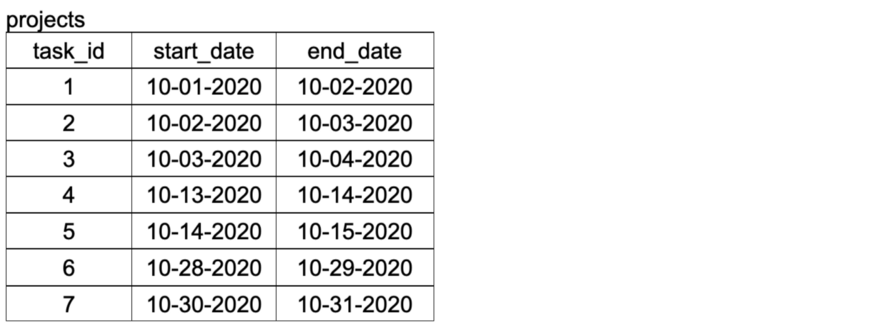
    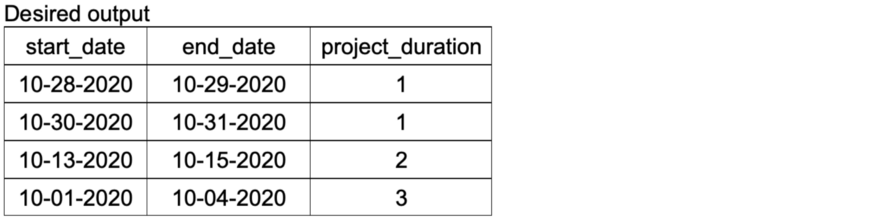

In [ ]:
import pandas as pd

# Создаём DataFrame как в примере
data = {
    'task_id': [1,2,3,4,5,6,7],
    'start_date': ['10-01-2020','10-02-2020','10-03-2020','10-13-2020','10-14-2020','10-28-2020','10-30-2020'],
    'end_date'  : ['10-02-2020','10-03-2020','10-04-2020','10-14-2020','10-15-2020','10-29-2020','10-31-2020']
}
projects = pd.DataFrame(data)

# Преобразуем колонки в datetime
projects['start_date'] = pd.to_datetime(projects['start_date'], format='%m-%d-%Y')
projects['end_date']   = pd.to_datetime(projects['end_date'],   format='%m-%d-%Y')

# Сортируем по end_date (важно для корректного объединения подряд идущих дат)
projects = projects.sort_values('end_date').reset_index(drop=True)

# Для группировки: если разрыв между текущим end_date и предыдущим end_date != 1 день -> новый проект
prev_end = projects['end_date'].shift(1)
gap = (projects['end_date'] - prev_end).dt.days  # NaN для первой строки
# Начало новой группы там, где gap != 1 (или для первой строки)
projects['new_group'] = (gap != 1)  # True = новая группа (первый элемент тоже True because gap is NaN)
# Нумеруем группы (cumulative sum of new_group)
projects['project_id'] = projects['new_group'].cumsum()

# Агрегируем для каждого проекта: min(start_date), max(end_date) и длительность в днях
agg = projects.groupby('project_id').agg(
    start_date = ('start_date', 'min'),
    end_date   = ('end_date', 'max')
).reset_index(drop=True)

agg['project_duration'] = (agg['end_date'] - agg['start_date']).dt.days

# Приводим даты обратно в строковый формат как в примере (если нужно)
agg['start_date'] = agg['start_date'].dt.strftime('%m-%d-%Y')
agg['end_date']   = agg['end_date'].dt.strftime('%m-%d-%Y')

# Сортировка результата: сначала по project_duration ASC, при равенстве — по start_date ASC
# (Если хочешь start_date DESC при равенстве — замени ascending=[True, True] на [True, False])
result = agg.sort_values(by=['project_duration', 'start_date'], ascending=[True, True]).reset_index(drop=True)

result[['start_date', 'end_date', 'project_duration']]


,start_date,end_date,project_duration
0,10-28-2020,10-29-2020,1
1,10-30-2020,10-31-2020,1
2,10-13-2020,10-15-2020,2
3,10-01-2020,10-04-2020,3


#  Time series  - related instance methods

## 1. Shifting/ lagging 

In [ ]:
 ts = pd.Series(range(len(rng)), index=rng)

NameError: name 'rng' is not defined

In [ ]:
ts = ts[:5]
ts.shift(1)

2011-01-31    NaN
2011-02-28    0.0
2011-03-31    1.0
2011-04-29    2.0
2011-05-31    3.0
Freq: BM, dtype: float64

In [ ]:
 ts.shift(5, freq="D")

2011-02-05    0
2011-03-05    1
2011-04-05    2
2011-05-04    3
2011-06-05    4
dtype: int64

In [ ]:
 ts.shift(5, freq=pd.offsets.BDay())

2011-02-07    0
2011-03-07    1
2011-04-07    2
2011-05-06    3
2011-06-07    4
dtype: int64

In [ ]:
 ts.shift(5, freq="BM")

2011-06-30    0
2011-07-29    1
2011-08-31    2
2011-09-30    3
2011-10-31    4
Freq: BM, dtype: int64

## 2. Frequency conversion

In [ ]:
dr = pd.date_range("1/1/2010", periods=3, freq=3*pd.offsets.BDay())

In [ ]:
ts = pd.Series(np.random.randn(3), index=dr)
ts    

2010-01-01    0.753869
2010-01-06    0.199928
2010-01-11    0.558205
Freq: 3B, dtype: float64

In [ ]:
 ts.asfreq(pd.offsets.BDay())

2010-01-01    0.753869
2010-01-04         NaN
2010-01-05         NaN
2010-01-06    0.199928
2010-01-07         NaN
2010-01-08         NaN
2010-01-11    0.558205
Freq: B, dtype: float64

In [ ]:
 ts.asfreq(pd.offsets.BDay(), method="pad")

2010-01-01    0.753869
2010-01-04    0.753869
2010-01-05    0.753869
2010-01-06    0.199928
2010-01-07    0.199928
2010-01-08    0.199928
2010-01-11    0.558205
Freq: B, dtype: float64

## 3. Resampling 

In [ ]:
rng = pd.date_range("1/1/2012", periods=100, freq="S")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts.resample("5Min").sum()

2012-01-01    26684
Freq: 5T, dtype: int64

In [ ]:
ts.resample("5Min").mean()

2012-01-01    266.84
Freq: 5T, dtype: float64

In [ ]:
ts.resample("5Min").ohlc()

,open,high,low,close
2012-01-01,268,499,3,263


### 3.1. Upsampling 

In [ ]:
# from secondly to every 250 milliseconds
ts[:2].resample("250L").asfreq()

2012-01-01 00:00:00.000    268.0
2012-01-01 00:00:00.250      NaN
2012-01-01 00:00:00.500      NaN
2012-01-01 00:00:00.750      NaN
2012-01-01 00:00:01.000    120.0
Freq: 250L, dtype: float64

In [ ]:
ts[:2].resample("250L").ffill()

2012-01-01 00:00:00.000    268
2012-01-01 00:00:00.250    268
2012-01-01 00:00:00.500    268
2012-01-01 00:00:00.750    268
2012-01-01 00:00:01.000    120
Freq: 250L, dtype: int64

In [ ]:
ts[:2].resample("250L").ffill(limit=2)

2012-01-01 00:00:00.000    268.0
2012-01-01 00:00:00.250    268.0
2012-01-01 00:00:00.500    268.0
2012-01-01 00:00:00.750      NaN
2012-01-01 00:00:01.000    120.0
Freq: 250L, dtype: float64

### 3.2. Sparse resampling 

In [ ]:
rng = pd.date_range("2014-1-1", periods=100, freq="D") + pd.Timedelta("1s")
ts = pd.Series(range(100), index=rng)

In [ ]:
ts.resample("3T").sum()

2014-01-01 00:00:00     0
2014-01-01 00:03:00     0
2014-01-01 00:06:00     0
2014-01-01 00:09:00     0
2014-01-01 00:12:00     0
                       ..
2014-04-09 23:48:00     0
2014-04-09 23:51:00     0
2014-04-09 23:54:00     0
2014-04-09 23:57:00     0
2014-04-10 00:00:00    99
Freq: 3T, Length: 47521, dtype: int64

In [ ]:
from functools import partial
from pandas.tseries.frequencies import to_offset
def round(t, freq):
    freq = to_offset(freq)
    return pd.Timestamp((t.value // freq.delta.value)*freq.delta.value)

ts.groupby(partial(round, freq="3T")).sum()

2014-01-01     0
2014-01-02     1
2014-01-03     2
2014-01-04     3
2014-01-05     4
              ..
2014-04-06    95
2014-04-07    96
2014-04-08    97
2014-04-09    98
2014-04-10    99
Length: 100, dtype: int64

### 3.3. Aggregation  

In [ ]:
 df = pd.DataFrame(
     np.random.randn(1000, 3),
     index=pd.date_range("1/1/2012", freq="S", periods=1000),
     columns=["A", "B", "C"],
 )   

In [ ]:
r = df.resample("3T")
r.mean()

,A,B,C
2012-01-01 00:00:00,0.006581,0.082790,0.060900
2012-01-01 00:03:00,0.086544,0.023713,-0.094236
2012-01-01 00:06:00,-0.053359,0.011758,-0.100756
2012-01-01 00:09:00,0.018094,0.079781,-0.042029
2012-01-01 00:12:00,0.252062,0.165298,-0.022088
2012-01-01 00:15:00,-0.189322,-0.048008,0.226700


In [ ]:
r["A"].mean()

2012-01-01 00:00:00    0.006581
2012-01-01 00:03:00    0.086544
2012-01-01 00:06:00   -0.053359
2012-01-01 00:09:00    0.018094
2012-01-01 00:12:00    0.252062
2012-01-01 00:15:00   -0.189322
Freq: 3T, Name: A, dtype: float64

In [ ]:
 r[["A", "B"]].mean()

,A,B
2012-01-01 00:00:00,0.006581,0.082790
2012-01-01 00:03:00,0.086544,0.023713
2012-01-01 00:06:00,-0.053359,0.011758
2012-01-01 00:09:00,0.018094,0.079781
2012-01-01 00:12:00,0.252062,0.165298
2012-01-01 00:15:00,-0.189322,-0.048008


In [ ]:
 r.agg([np.sum, np.mean])

A                    B                    C  \
                           sum      mean        sum      mean        sum   
2012-01-01 00:00:00   1.184530  0.006581  14.902214  0.082790  10.962072   
2012-01-01 00:03:00  15.577970  0.086544   4.268406  0.023713 -16.962409   
2012-01-01 00:06:00  -9.604629 -0.053359   2.116471  0.011758 -18.136061   
2012-01-01 00:09:00   3.256889  0.018094  14.360559  0.079781  -7.565144   
2012-01-01 00:12:00  45.371077  0.252062  29.753627  0.165298  -3.975775   
2012-01-01 00:15:00 -18.932204 -0.189322  -4.800755 -0.048008  22.669970   

                               
                         mean  
2012-01-01 00:00:00  0.060900  
2012-01-01 00:03:00 -0.094236  
2012-01-01 00:06:00 -0.100756  
2012-01-01 00:09:00 -0.042029  
2012-01-01 00:12:00 -0.022088  
2012-01-01 00:15:00  0.226700

In [ ]:
r.agg({"A": "sum", "B": "std"})

,A,B
2012-01-01 00:00:00,1.184530,0.854300
2012-01-01 00:03:00,15.577970,0.937991
2012-01-01 00:06:00,-9.604629,1.012145
2012-01-01 00:09:00,3.256889,1.006631
2012-01-01 00:12:00,45.371077,0.937387
2012-01-01 00:15:00,-18.932204,1.003031


# Exercises (IWS (I PART)): 

3. Given the following two tables, write a statement to return the fraction of students, rounded to two decimal places, who attended school (attendance = 1) on their birthday.
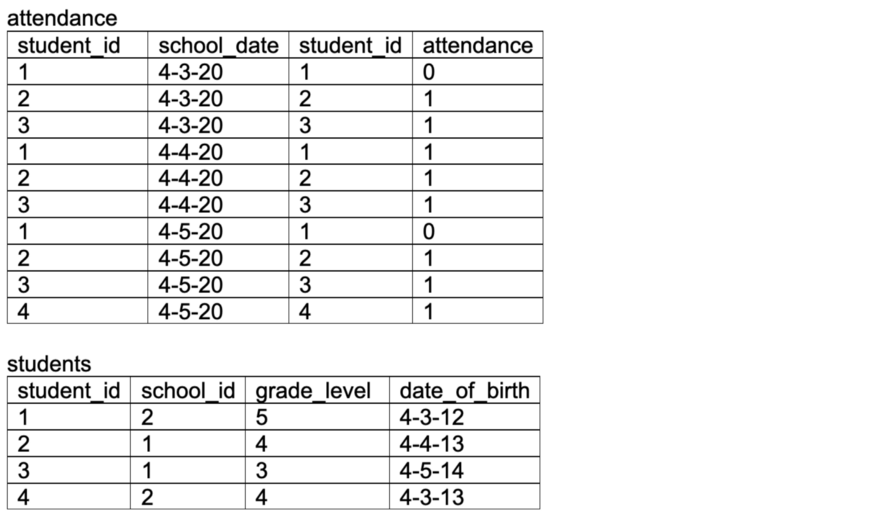

In [ ]:
import pandas as pd

# Объединяем таблицы
merged = attendance.merge(students, on='student_id')

# Фильтруем только тех, кто присутствовал
attended = merged[merged['attendance'] == 1]

# Извлекаем месяц-день из дат
attended['school_md'] = attended['school_date'].str[:4]
attended['birth_md'] = attended['date_of_birth'].str[:4]

# Проверяем совпадение дня рождения с днем посещения
birthday_attendance = (attended['school_md'] == attended['birth_md']).sum()

# Общее количество уникальных студентов, которые посещали школу
total_students = attended['student_id'].nunique()

# Вычисляем долю и округляем
fraction = round(birthday_attendance / total_students, 2)

# Выводим результат в виде DataFrame
result = pd.DataFrame({'fraction': [fraction]})
result

C:\Users\aslan\AppData\Local\Temp\ipykernel_12424\293155491.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attended['school_md'] = attended['school_date'].str[:4]
C:\Users\aslan\AppData\Local\Temp\ipykernel_12424\293155491.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attended['birth_md'] = attended['date_of_birth'].str[:4]


,fraction
0,0.5


4. Write a statement to return the average cycle time across each month. Cycle time is the time elapsed between one user joining and their invitees joining. Users who joined without an invitation have a zero in the “invited by” column.
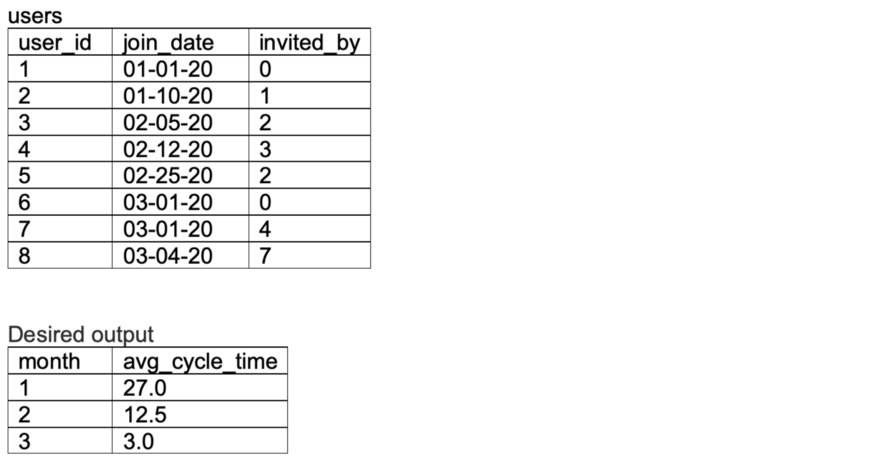

In [ ]:
import pandas as pd

# Создаем таблицу users
users = pd.DataFrame({
    'user_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'join_date': ['01-01-20', '01-10-20', '02-05-20', '02-12-20', '02-25-20', '03-01-20', '03-01-20', '03-04-20'],
    'invited_by': [0, 1, 2, 3, 2, 0, 4, 7]
})

# Преобразуем join_date в datetime
users['join_date'] = pd.to_datetime(users['join_date'], format='%m-%d-%y')

# Создаем self-join для связи пользователей с их пригласителями
merged = users.merge(users, left_on='invited_by', right_on='user_id', suffixes=('_invitee', '_inviter'))

# Вычисляем cycle time в днях
merged['cycle_time'] = (merged['join_date_invitee'] - merged['join_date_inviter']).dt.days

# Извлекаем месяц из даты присоединения пригласителя
merged['month'] = merged['join_date_inviter'].dt.month

# Группируем по месяцам и вычисляем среднее cycle time
result = merged.groupby('month')['cycle_time'].mean().reset_index()
result.columns = ['month', 'avg_cycle_time']
result['avg_cycle_time'] = result['avg_cycle_time'].round(1)

result

,month,avg_cycle_time
0,1,27.0
1,2,12.5
2,3,3.0
